# Quick look at vpo triad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
conns = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/connections_princeton.csv")
#conns.rename(columns={"root_id": "id"}, inplace=True)
conns

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940630432382,720575940618518557,ME_L,67,ACH
2,720575940627314521,720575940626337738,ME_L,10,GABA
3,720575940620280405,720575940620204726,ME_L,15,ACH
4,720575940636942447,720575940613789411,LA_L,1,GLUT
...,...,...,...,...,...
5342441,720575940610739918,720575940617129885,PLP_L,5,ACH
5342442,720575940653332385,720575940623905719,CRE_R,2,ACH
5342443,720575940622485887,720575940631031803,ME_R,9,ACH
5342444,720575940620020534,720575940636489140,SMP_L,2,ACH


In [3]:
types = pd.read_csv("/Users/ggutierr/Documents/FlyWireData/consolidated_cell_types.csv")
types.rename(columns={"root_id": "id"}, inplace=True)
types

,id,primary_type,additional_type(s)
0,720575940596125868,T5c,NaN
1,720575940597856265,Tm16,NaN
2,720575940597944841,Tm7,CB3851
3,720575940598267657,TmY15,NaN
4,720575940599333574,Tm1,NaN
...,...,...,...
137682,720575940661335681,CB0180,NaN
137683,720575940661336193,TmY3,NaN
137684,720575940661337217,KCab-p,NaN
137685,720575940661338497,CB0904,NaN


In [4]:
# get rows where types contains 'vpo'
types[types['primary_type'].str.contains('vpo')]

,id,primary_type,additional_type(s)
38702,720575940619415679,vpoEN,NaN
107459,720575940632385943,vpoEN,NaN
115373,720575940634829168,vpoEN,NaN
116960,720575940635403230,vpoEN,NaN


In [6]:
types[types['additional_type(s)'].str.contains('vpo|pMN', case=False, na=False)]

,id,primary_type,additional_type(s)
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
20795,720575940614618741,LHAV4c2,aSP8_vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN"
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN"
25164,720575940615894877,CB1385,vpoIN
36406,720575940618812888,CB1385,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN"
38952,720575940619486891,DNp13,pMN1/DNp13
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN"


In [23]:
# get all the vpo types 
vpo_neurons = types[types['additional_type(s)'].str.contains('vpo', case=False, na=False)|types['primary_type'].str.contains('vpo',na=False)]
vpo_neurons

,id,primary_type,additional_type(s)
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN"
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN"
20795,720575940614618741,LHAV4c2,aSP8_vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN"
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN"
25164,720575940615894877,CB1385,vpoIN
36406,720575940618812888,CB1385,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN"
38702,720575940619415679,vpoEN,NaN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN"


In [24]:
# make a new column to neaten up the names
vpo_neurons['cell_type'] = np.where(vpo_neurons['primary_type'].str.contains('vpo', case=False, na=False), vpo_neurons['primary_type'], 'Nan')
vpo_neurons

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/3268935582.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['primary_type'].str.contains('vpo', case=False, na=False), vpo_neurons['primary_type'], 'Nan')


,id,primary_type,additional_type(s),cell_type
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN",Nan
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",Nan
20795,720575940614618741,LHAV4c2,aSP8_vpoIN,Nan
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN",Nan
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN",Nan
25164,720575940615894877,CB1385,vpoIN,Nan
36406,720575940618812888,CB1385,vpoIN,Nan
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN",Nan
38702,720575940619415679,vpoEN,NaN,vpoEN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN",Nan


In [25]:
vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoDN', na=False), 'vpoDN', vpo_neurons['cell_type'])
vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoIN', na=False), 'vpoIN', vpo_neurons['cell_type'])
vpo_neurons

/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/2865508171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoDN', na=False), 'vpoDN', vpo_neurons['cell_type'])
/var/folders/qb/p6dbns6n14n6pl5jy5tkwp78xfrsnf/T/ipykernel_50339/2865508171.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpo_neurons['cell_type'] = np.where(vpo_neurons['additional_type(s)'].str.contains('vpoIN', na=False), 'vpoIN', vpo_ne

,id,primary_type,additional_type(s),cell_type
13854,720575940612403427,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
16443,720575940613170498,DNp37,"vpoDN, pMN2, pMN2/vpoDN",vpoDN
20795,720575940614618741,LHAV4c2,aSP8_vpoIN,vpoIN
21333,720575940614752395,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
22854,720575940615200059,LHAV4c2,"vpoIN, aSP8_vpoIN",vpoIN
25164,720575940615894877,CB1385,vpoIN,vpoIN
36406,720575940618812888,CB1385,vpoIN,vpoIN
36555,720575940618851425,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN
38702,720575940619415679,vpoEN,NaN,vpoEN
59306,720575940623256202,AVLP008,"vpoIN, aSP8_vpoIN",vpoIN


In [ ]:
# grab connections between vpo neurons
vpo_conns = conns[conns['pre_root_id'].isin(vpo_neurons['id']) & conns['post_root_id'].isin(vpo_neurons['id'])]
vpo_conns

,pre_root_id,post_root_id,neuropil,syn_count,nt_type
213932,720575940634829168,720575940627496829,VES_L,3,ACH
292231,720575940635403230,720575940627496829,VES_L,1,ACH
601724,720575940628256763,720575940619415679,SIP_R,5,GABA
621368,720575940619415679,720575940613170498,LAL_R,2,ACH
845664,720575940615894877,720575940627496829,SCL_L,6,GABA
...,...,...,...,...,...
4771451,720575940627718394,720575940627496829,ICL_L,2,GABA
4836380,720575940632385943,720575940628542807,AVLP_R,1,ACH
4860576,720575940636705502,720575940613170498,SCL_R,2,GABA
4970055,720575940628542807,720575940613170498,SIP_R,26,GABA


In [29]:
# groupby to eliminate duplicate pairs
vpo_conns = vpo_conns[['pre_root_id', 'post_root_id', 'syn_count']].groupby(['pre_root_id', 'post_root_id']).sum().reset_index()
vpo_conns

,pre_root_id,post_root_id,syn_count
0,720575940612403427,720575940613170498,51
1,720575940614752395,720575940613170498,61
2,720575940615200059,720575940627496829,11
3,720575940615894877,720575940627496829,14
4,720575940618812888,720575940613170498,5
5,720575940618851425,720575940613170498,21
6,720575940619415679,720575940613170498,62
7,720575940619415679,720575940627496829,7
8,720575940623256202,720575940627496829,31
9,720575940627718394,720575940627496829,21


In [30]:
# merge cell_types column onto connections dataframe
vpo_type_conns = vpo_conns.merge(vpo_neurons[['id', 'cell_type']], left_on='pre_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'pre_type'})
vpo_type_conns = vpo_type_conns.merge(vpo_neurons[['id', 'cell_type']], left_on='post_root_id', right_on='id').drop(columns=['id']).rename(columns={'cell_type': 'post_type'})
vpo_type_conns

,pre_root_id,post_root_id,syn_count,pre_type,post_type
0,720575940612403427,720575940613170498,51,vpoIN,vpoDN
1,720575940614752395,720575940613170498,61,vpoIN,vpoDN
2,720575940615200059,720575940627496829,11,vpoIN,vpoDN
3,720575940615894877,720575940627496829,14,vpoIN,vpoDN
4,720575940618812888,720575940613170498,5,vpoIN,vpoDN
5,720575940618851425,720575940613170498,21,vpoIN,vpoDN
6,720575940619415679,720575940613170498,62,vpoEN,vpoDN
7,720575940619415679,720575940627496829,7,vpoEN,vpoDN
8,720575940623256202,720575940627496829,31,vpoIN,vpoDN
9,720575940627718394,720575940627496829,21,vpoIN,vpoDN


In [31]:
# groupby cell type and sum the weights
vpo_type_conns = vpo_type_conns[['pre_type', 'post_type', 'syn_count']].groupby(['pre_type', 'post_type']).sum().reset_index()
vpo_type_conns

,pre_type,post_type,syn_count
0,vpoEN,vpoDN,204
1,vpoEN,vpoEN,15
2,vpoEN,vpoIN,18
3,vpoIN,vpoDN,416
4,vpoIN,vpoEN,11


{('vpoEN', 'vpoDN'): Text(0.2784414701106297, 0.29990603767068363, '204'),
 ('vpoEN', 'vpoEN'): Text(-0.44311705977874066, 0.6857722090517321, '15'),
 ('vpoEN', 'vpoIN'): Text(-0.5000000000000006, 0.04298006685518263, '18'),
 ('vpoIN', 'vpoDN'): Text(0.22155852988936975, -0.3428861045258658, '416'),
 ('vpoIN', 'vpoEN'): Text(-0.5000000000000006, 0.04298006685518263, '11')}

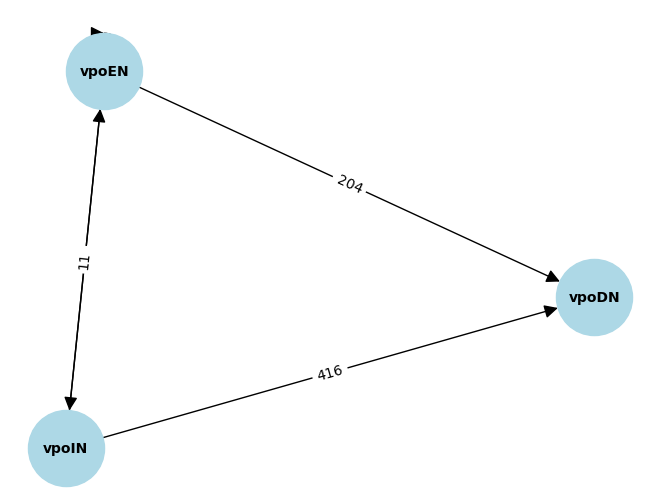

In [33]:
# make a networkx graph
G = nx.from_pandas_edgelist(vpo_type_conns, 'pre_type', 'post_type', ['syn_count'], create_using=nx.DiGraph())
pos = nx.spring_layout(G, seed=42)  # positions for all nodes

# draw the nodes and edges
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight="bold", arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'syn_count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

